In [1]:
#pip install pandas xarray numba

In [2]:
#conda  install xarray

In [3]:
import os
import glob
import json
import xarray as xr
import numpy as np

import colorcet as cc
from typing import Tuple

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap
from matplotlib.gridspec import GridSpec


In [4]:
class ErrorMetricPlotter:
    def __init__(self, data_monthly_dir, monthly_var_list, hourly_var_list, exp_name_map,
                 regnam="global", metric="RMSE", data_6hourly_dir=None,
                 year_range=(2008, 2017), var_alias=None):
        self.data_monthly_dir = data_monthly_dir
        self.data_6hourly_dir = data_6hourly_dir
        self.monthly_var_list = monthly_var_list
        self.hourly_var_list = hourly_var_list
        self.exp_name_map = exp_name_map
        self.regnam = regnam
        self.metric = metric
        self.year_range = year_range
        self.var_alias = var_alias or {}

        self.data = self._load_monthly_metric()
        self.hourly_data = self._load_6hourly_metric() if data_6hourly_dir else None

        self.normalized = metric in ["RMSE", "MEAN"]
        if self.normalized:
            self._normalize_by_mean()

    def _load_monthly_metric(self):
        data = {var: {} for var in self.monthly_var_list}
        for var in self.monthly_var_list:
            for exp in self.exp_name_map.keys():
                path = os.path.join(self.data_monthly_dir, f"{var}_{self.regnam}_{self.metric}_{exp}.nc")
                if os.path.exists(path):
                    try:
                        ds = xr.open_dataset(path)
                        data[var][exp] = ds[var].sel(season=["DJF", "MAM", "JJA", "SON"]).values
                    except Exception as e:
                        print(f"[ERROR] Failed to load {path}: {e}")
        return data

    def _load_6hourly_metric(self):
        data = {var: {} for var in self.hourly_var_list}
        for var in self.hourly_var_list:
            for exp in self.exp_name_map.keys():
                vals = []
                for year in range(self.year_range[0], self.year_range[1] + 1):
                    path = os.path.join(self.data_6hourly_dir, f"{var}_{self.regnam}_{self.metric}_{exp}_{year}.nc")
                    if os.path.exists(path):
                        try:
                            ds = xr.open_dataset(path)
                            vals.append(ds[var].sel(season=["DJF", "MAM", "JJA", "SON"]).values)
                        except Exception as e:
                            print(f"[ERROR] Failed to read {path}: {e}")
                if vals:
                    stacked = np.stack(vals)
                    mean_val = np.nanmean(stacked, axis=0)
                    data[var][exp] = mean_val
        return data

    def _normalize_by_mean(self):
        for var_list, data in [(self.monthly_var_list, self.data), (self.hourly_var_list, self.hourly_data or {})]:
            for var in var_list:
                ref_vals = [np.nanmean(data[var][exp]) for exp in self.exp_name_map.keys() if exp in data[var]]
                if ref_vals:
                    ref_mean = np.nanmean(ref_vals)
                    for exp in self.exp_name_map.keys():
                        if exp in data[var]:
                            data[var][exp] /= ref_mean

    def _get_discrete_colormap(self, cmap, levels):
        cmap_obj = plt.get_cmap(cmap)
        return ListedColormap(cmap_obj(np.linspace(0, 1, len(levels) - 1)))

    def _draw_triangles(
            self, 
            ax, 
            data, 
            var_list, 
            title, 
            norm, 
            cmap, 
            fontz, 
            exp_name_map,
            panel_label
        ):
        patches, values = [], []
        triangle_coords = [
            [(0, 0), (1, 0), (0.5, 0.5)],
            [(1, 0), (1, 1), (0.5, 0.5)],
            [(1, 1), (0, 1), (0.5, 0.5)],
            [(0, 1), (0, 0), (0.5, 0.5)]
        ]
        for j, exp in enumerate(self.exp_name_map.keys()):
            for i, var in enumerate(var_list):
                val = data.get(var, {}).get(exp)
                if val is not None and len(val) == 4:
                    for k in range(4):
                        tri = np.array(triangle_coords[k]) + np.array([i, j])
                        patches.append(Polygon(tri, closed=True))
                        values.append(val[k])
        collection = PatchCollection(patches, cmap=cmap, norm=norm, edgecolor='k', linewidths=0.2)
        collection.set_array(np.array(values))
        ax.add_collection(collection)
        ax.set_xlim(0, len(var_list))
        ax.set_ylim(0, len(self.exp_name_map.keys()))
        display_labels = [self.var_alias.get(v, v) for v in var_list]
        ax.set_xticks(np.arange(len(var_list)) + 0.5)
        ax.set_xticklabels(display_labels, rotation=60, ha='right', fontsize=fontz)
        ax.set_yticks(np.arange(len(self.exp_name_map.keys())) + 0.5)
        ax.set_yticklabels([self.exp_name_map.get(e, e) for e in self.exp_name_map.keys()] if exp_name_map else self.exp_name_map.keys(), fontsize=fontz)
        ax.invert_yaxis()
        ax.set_title(f"({panel_label}) {title}", fontsize=fontz + 2, loc="left")
        return collection

    def _draw_season_legend(self, ax):
        tri_coords = [
            [(0, 0), (1, 0), (0.5, 0.5)],
            [(1, 0), (1, 1), (0.5, 0.5)],
            [(1, 1), (0, 1), (0.5, 0.5)],
            [(0, 1), (0, 0), (0.5, 0.5)]
        ]
        seasons = ["DJF", "MAM", "JJA", "SON"]
        patches = [Polygon(coords, closed=True) for coords in tri_coords]
        pc = PatchCollection(patches, edgecolor="black", facecolor="white", linewidths=0.5)
        ax.add_collection(pc)
        for i, season in enumerate(seasons):
            coords = np.mean(tri_coords[i], axis=0)
            ax.text(coords[0], coords[1], season, fontsize=7, ha="center", va="center")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect('equal')
        ax.axis("off")

    def plot(
            self, 
            out_path, 
            fig_name = None,
            cmap="viridis",
            vmin=0, 
            vmax=2.0, 
            fontz=9,
            levels=None
        ):
        if levels is None:
            levels = np.linspace(vmin, vmax, 6)
        norm = BoundaryNorm(boundaries=levels, ncolors=len(levels) - 1)
        cmap = self._get_discrete_colormap(cmap, levels)

        width_factor = 0.3
        fig_width = max(len(self.monthly_var_list), len(self.hourly_var_list)) * width_factor + 2
        fig_height = len(self.exp_name_map.keys()) * 0.9 + 1.2

        fig = plt.figure(figsize=(fig_width, fig_height))
        gs = GridSpec(2, 1, height_ratios=[1, 1], figure=fig)

        ax1 = fig.add_subplot(gs[0, 0])  # Top: 6-hourly metrics
        ax2 = fig.add_subplot(gs[1, 0])  # Bottom: Monthly metrics

        # === Custom axes for colorbar (thinner and slightly lower) and legend ===
        ax_cbar = fig.add_axes([0.93, 0.12, 0.015, 0.58])     # [left, bottom, width, height]
        ax_legend = fig.add_axes([0.87, 0.76, 0.12*1.4, 0.08*1.4])     # Above colorbar

        # Draw metric triangles
        pc1 = self._draw_triangles(
            ax1, 
            self.hourly_data, 
            self.hourly_var_list,
            "Model State (pressure level)", 
            norm, 
            cmap, 
            fontz,
            self.exp_name_map, 
            "a"
        )
        self._draw_triangles(
            ax2, 
            self.data, 
            self.monthly_var_list,
            "Model State (surface level)",
            norm,
            cmap, 
            fontz,
            self.exp_name_map,
            "b"
        )

        # Draw legend and colorbar
        self._draw_season_legend(ax_legend)
        cbar = fig.colorbar(pc1, cax=ax_cbar, orientation="vertical", ticks=levels)
        cbar.set_label(f"{self.metric} (normalized by mean)" if self.normalized else self.metric, fontsize=fontz)
        cbar.ax.tick_params(labelsize=fontz)
        
        fig.subplots_adjust(hspace=0.5) 
        
        # Save the plot
        os.makedirs(out_path, exist_ok=True)
        if fig_name is not None:
            pdf_path = os.path.join(out_path, fig_name)
        else:
            pdf_path = os.path.join(out_path, f"{self.metric}_heatmap_seasonal_mean.pdf")
        plt.savefig(pdf_path, dpi=600, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f"[INFO] Saved plot to: {pdf_path}")

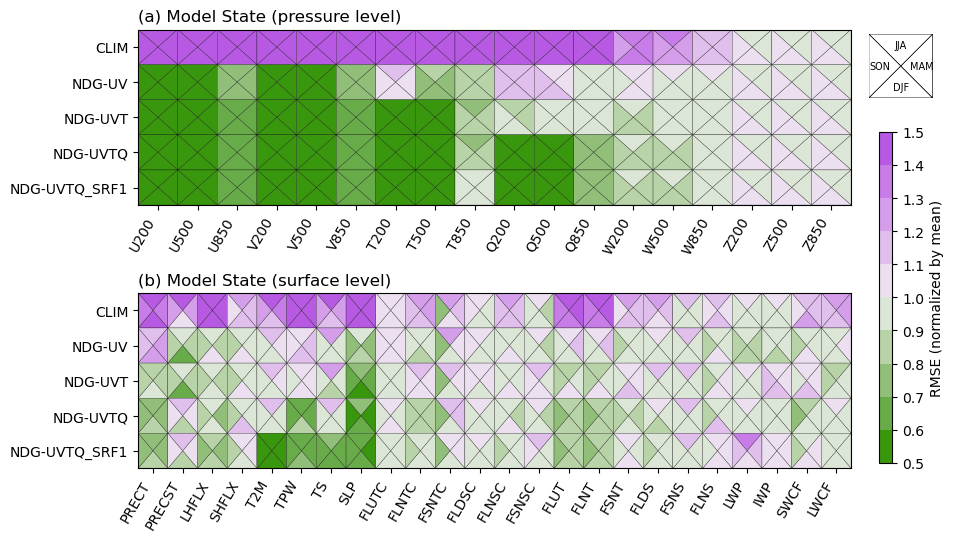

[INFO] Saved plot to: ./Figure_04.pdf


In [5]:
# === Run Script ===
if __name__ == "__main__":
    top_path = "/home/x-szhang3/nudging_analysis"
    data_path = f"{top_path}/nudging_evaluation/data/error_metrics"
    fig_path = "./"
    os.makedirs(fig_path, exist_ok=True)

    # === Time and frequency ===
    tstart = "2008-01"
    tend = "2017-12"
    freq = "monthly"

    # === Load metadata ===
    exp_json = "/home/x-szhang3/nudging_analysis/nudge_exp_info.json"
    with open(exp_json, "r") as f:
        exp_dict = json.load(f)

    # === Variable lists ===
    monthly_var_list = [
        'PRECT', 'PRECST', 'LHFLX', 'SHFLX',
        'TREFHT', 'TMQ', 'TS', 'PSL',
        'FLUTC', 'FLNTC', 'FSNTC', 'FLDSC', 'FLNSC', 'FSNSC',
        'FLUT', 'FLNT', 'FSNT', 'FLDS', 'FSNS', 'FLNS',
        'TGCLDLWP', 'TGCLDIWP', 'SWCF', 'LWCF'
    ]
    hourly_var_list = [
        "U200", "U500", "U850",
        "V200", "V500", "V850",
        "T200", "T500", "T850",
        "Q200", "Q500", "Q850",
        "OMEGA200", "OMEGA500", "OMEGA850",
        "Z200", "Z500", "Z850"
    ]

    # === Aliases for prettier plot labels ===
    var_alias = {
        "OMEGA200": "W200", "OMEGA500": "W500", "OMEGA850": "W850",
        "TREFHT": "T2M", "TMQ": "TPW", "PSL": "SLP", "TGCLDLWP": "LWP",
        "TGCLDIWP": "IWP",
    }

    # === Experiment info ===
    exp_name_map = {
        "CLIM": "CLIM",
        "NDGUV": "NDG-UV",
        "NDGUVT": "NDG-UVT",
        "NDGUVTQ": "NDG-UVTQ",
        "NDGUVTQ_SRF1": "NDG-UVTQ_SRF1"
    }

    # === Metric settings ===
    regnam = "global"
    metric = "RMSE"
    cmap = cc.cm["CET_D2"]
    vmin = 0.5
    vmax = 1.5
    levels = np.linspace(vmin, vmax, 11)

    # === Run plotter ===
    fig_name = "Figure_04.pdf"
    plotter = ErrorMetricPlotter(
        data_monthly_dir=f"{data_path}/{freq}",
        data_6hourly_dir=f"{data_path}/6hourly",
        monthly_var_list=monthly_var_list,
        hourly_var_list=hourly_var_list,
        exp_name_map=exp_name_map,
        regnam=regnam,
        metric=metric,
        year_range=(2008, 2017),
        var_alias=var_alias
    )

    plotter.plot(
        out_path=fig_path,
        fig_name=fig_name,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        fontz=10,
        levels=levels
    )


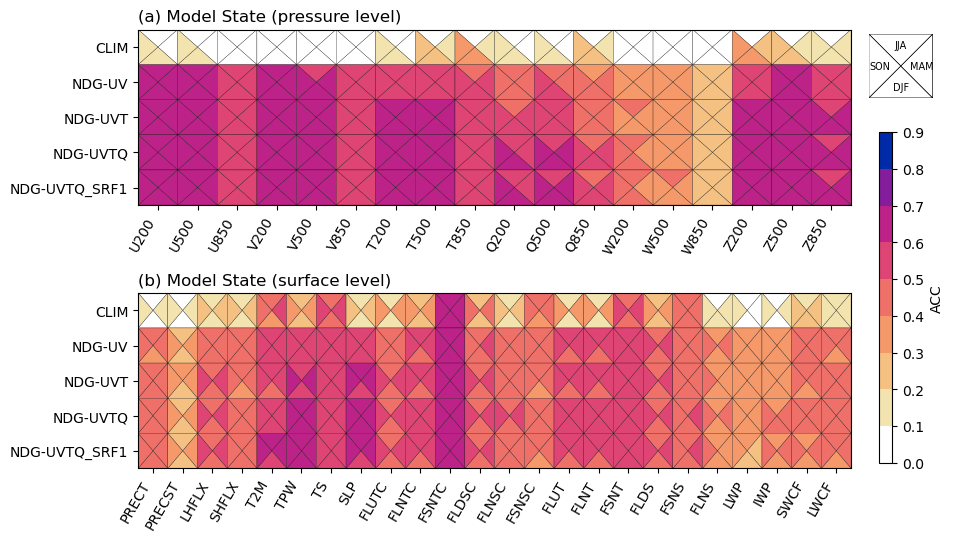

[INFO] Saved plot to: ./Figure_C1.pdf


In [6]:
if __name__ == "__main__":
    # === Set paths ===
    top_path = "/home/x-szhang3/nudging_analysis"
    data_path = f"{top_path}/nudging_evaluation/data/error_metrics"
    fig_path = "./"
    os.makedirs(fig_path, exist_ok=True)

    # === Time and frequency ===
    tstart = "2008-01"
    tend = "2017-12"
    freq = "monthly"

    # === Load metadata ===
    exp_json = "/home/x-szhang3/nudging_analysis/nudge_exp_info.json"
    with open(exp_json, "r") as f:
        exp_dict = json.load(f)

    # === Variable lists ===
    monthly_var_list = [
        'PRECT', 'PRECST', 'LHFLX', 'SHFLX',
        'TREFHT', 'TMQ', 'TS', 'PSL',
        'FLUTC', 'FLNTC', 'FSNTC', 'FLDSC', 'FLNSC', 'FSNSC',
        'FLUT', 'FLNT', 'FSNT', 'FLDS', 'FSNS', 'FLNS',
        'TGCLDLWP', 'TGCLDIWP', 'SWCF', 'LWCF'
    ]
    hourly_var_list = [
        "U200", "U500", "U850",
        "V200", "V500", "V850",
        "T200", "T500", "T850",
        "Q200", "Q500", "Q850",
        "OMEGA200", "OMEGA500", "OMEGA850",
        "Z200", "Z500", "Z850"
    ]

    # === Aliases for prettier plot labels ===
    var_alias = {
        "OMEGA200": "W200", "OMEGA500": "W500", "OMEGA850": "W850",
        "TREFHT": "T2M", "TMQ": "TPW", "PSL": "SLP", "TGCLDLWP": "LWP",
        "TGCLDIWP": "IWP",
    }

    # === Experiment info ===
    exp_list = ["CLIM", "NDGUV", "NDGUVT", "NDGUVTQ", "NDGUVTQ_SRF1"]
    exp_name_map = {
        "CLIM": "CLIM",
        "NDGUV": "NDG-UV",
        "NDGUVT": "NDG-UVT",
        "NDGUVTQ": "NDG-UVTQ",
        "NDGUVTQ_SRF1": "NDG-UVTQ_SRF1"
    }

    # === Metric settings ===
    regnam = "global"
    metric = "ACC" #"ACC" "MEAN", "BIAS", "RMSE", "ACC", "TSCORR", "STCORR"
    cmap = cc.cm["CET_L19"]
    cmap = cc.cm["CET_L17"]
    vmin = 0.0
    vmax = 0.9
    levels = np.linspace(vmin, vmax, 10)

    # === Run plotter ===
    fig_name = "Figure_C1.pdf"
    plotter = ErrorMetricPlotter(
        data_monthly_dir=f"{data_path}/{freq}",
        data_6hourly_dir=f"{data_path}/6hourly",
        monthly_var_list=monthly_var_list,
        hourly_var_list=hourly_var_list,
        exp_name_map=exp_name_map,
        regnam=regnam,
        metric=metric,
        year_range=(2008, 2017),
        var_alias=var_alias
    )

    plotter.plot(
        out_path=fig_path,
        fig_name=fig_name,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        fontz=10,
        levels=levels
    )